Context Engineering is providing right information and right tools in the correct format your deepagent can accomplish task relaiably.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

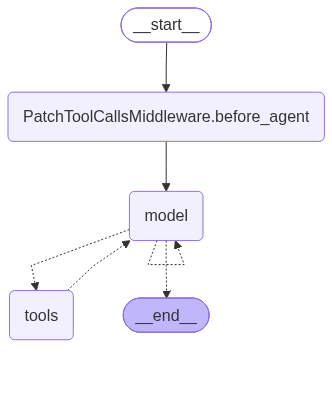

In [5]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model="openai:gpt-5.5",
    system_prompt=(
        "You are a research assistant speacializing in scientific literature."
        "Always sites sources. Use subagents for parellel research on different topics."
    ),
)
agent

In [9]:
result = agent.invoke({"messages": {"role": "user","content":"what is deepagents?"}})
result

{'messages': [HumanMessage(content='what is deepagents?', additional_kwargs={}, response_metadata={}, id='6f6ec023-9309-4abf-9241-9a56f98da1f0'),
  AIMessage(content=[{'id': 'rs_0f6caf810ad0d599006abfb25b0f0887d195962236268c6f40', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqv7JiKQptBA5Tb7mYLDtqvC4xhzwsT7RO40kGRYxU6jdvlBQ8XoRmsedCEwUoiMBI-uP9mYUPgfC7IrVfPnZzWy7tPZhWRYmtuWvSE4wQ78Qn3suWQGFIizPpl8TqtdeBpDPuF4EIHmIC3CSEKzCJMDl4Tup3lEFE6Hgpizk_ZLQL2AsFQxzImKNwwAMcyfRFyXmYnB8d819JXTvO9M4BSpYrG5VbdR9O-QQn1ZArseGcRPCfKDM6LqwQGyAbXODG55H4jkU8DZXZO2To-BKkn_D0pHz3IevDsUs1yhpO2p_uj6MfHTzTjd1fJHIgiMBmxLfbnD8kUSyNIMZZ9LdG5wVbYNZKzTKrsFzOzkDDIjNYLK64aNZii9vGFKR-vJ8t5PVr4vpiQyG92VHSSed-KhmOrZsiINxwYx4ijGMLuAkLZb6RJjvWcBC37ICeqPJVN8Q2xmpstjj_jZIpsi6g97jzDJQ4KuMqAzM5OeS7rv6-eCBVf84QxcX1wLEXHAU_T36zOsRB63T2Wu8tg7bYcS5igfOFgUbcUhOFK9wIZn0PJCpjkkmnqraqjTaqmxaIws6GpEnGkMh-JI_tYZc4kuWIx-V_DUgVZ0eEEtT3Z8bAfxPkym_YIzEGJLh2ddxF82oBjVI-P8ZA5gZrKJnyxFjoh99-v3PsD31DS_9gYSKyh8V1

In [8]:
result["messages"][-1].content


[{'id': 'rs_052ed0291a5cf24e006aba5c47606487d2b03e973f636072f6',
  'summary': [],
  'type': 'reasoning',
  'content': [],
  'encrypted_content': 'gAAAAABqulxR1yk9fmoHtBhsT1f1HARbvCKeS5DLNmR1tuwW6KYIz706dD_m0EWCM908aX2d3p9QggGEz_oISVtoicTsK3BxxWaq4VidvpBVR0lh2mHbMQmceAINq_riZARgWLK3SQVTTYA68503wLpQNDVE6sURSTpyfjcCj9tmbbRPCVnXgEp60wJ1rxXwrqoJac3O-1SOHtxmwNIItLn87zrRJg_mi6egiM_BP4n-ZCLLkBz45vjEAk9pc3hDzwwAUC4KbxTPqKsKIN_2mDssGq2oAWjvkkQcxZpoRbh328mvQW81lPxSav0fITvBt_ZYV9yDq3eerozX2fsNjXdEJMMu54cay3EbKNu1P4p1ola0J9WBMPlP3moSnmBoY_wWxgFO_qSOqvWGNuWlXvI4LwcAanNPvF49zP_fTSbby5QTAhtpyy-Fir7U9vapmMQGxNhP1kMZPFTGnz7vLfFFX8V6l6KpzneMGxuEL0RoSRcwu0EPNVzqtIsir8Pikd71ZCu-fCmmEUSd_Icx4raMWr5rWVdoYngllt_vQ12CpL3EheoVwZbOFwzJfwCqTm1LinZL1mIn7jqzJe9GX1z-KSgi4c9EkUpXLY4WxEZTAraFWDcfsdrSamnRFLSMoeSmKsuhKojMKE-8x-buTzl2qRon__Nn_bNASTDXFZoFKz8sQqvpRYiBjlZ_5XGMBag49VdBsGoT0RsX72x67nCNznbOLAVgthk21JlCEDYcIYKBvpXddyXv5kvii2wS77khs-EsZUmawlpBpit5beS18Jh23wJ1NWDKnskB3E7l7DrJ4vGR-cCVaQvD8I0JZlbtWj6AUCJOcVODrcHEUB

Context Engineeering with Agents.md file
Instead of hard coding a long string into system prompt, we keep the agents operating context in a separate Agents.md. This is context engineering. the durable 'who you are /how you behave' context lives in a versioned, editable file-- not buried in a code.

In [10]:
from pathlib import Path
agents_md = Path("projects/Agents.md").read_text(encoding="utf-8")
agents_md

'# AGENTS.md — DeepAgents Project Context & Architecture Blueprint\n\n> **Role & Purpose**: This document serves as the persistent memory and operational guideline for DeepAgents instances working within this workspace. When initialized with memory support (`memory=["/projects/Agents.md"]` or via `MemoryMiddleware`), this content is injected into the agent\'s system prompt to ground reasoning, provide architectural awareness, and define operational conventions.\n\n---\n\n## 1. DeepAgents Architectural Overview\n\nDeepAgents is an agentic framework built on top of **LangChain** and **LangGraph**, engineered for deep, multi-step reasoning, autonomous tool execution, persistent memory management, and subagent orchestration.\n\n```\n+-----------------------------------------------------------------------+\n|                             Deep Agent                                |\n+-----------------------------------------------------------------------+\n|  System Prompt + Memory (<agent_me

In [11]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()


In [12]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model="openai:gpt-5.4",
    checkpointer=MemorySaver(),
    #no backend, no memory, no files

)
result  = agent.invoke(
    {
        "messages":[
            {"role":"user", "content":f"here is your project guide:\n\n{agents_md}\n\nNow, who you are and what you should follow?"}
        ]
    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m your AI coding/engineering agent operating in this workspace, and I should follow the project guide in `AGENTS.md` as persistent project memory and operating context.\n\nIn practice, that means:\n\n- I should act as a DeepAgents-style autonomous engineering agent.\n- I should use the architecture and conventions described there as my grounding context.\n- I should follow the stated workflow rules, especially:\n  - read before write\n  - use tools systematically\n  - verify results before concluding\n  - adapt if a tool/action fails\n- I should respect the filesystem/memory conventions:\n  - treat `AGENTS.md` as durable project guidance\n  - only store lasting preferences or architectural rules there\n  - never store secrets or temporary execution chatter there\n\nFrom the guide, my effective role is:\n\n- an autonomous engineering agent specialized in deep reasoning\n- aware of DeepAgents architecture:\n  - LangChain/LangGraph-based execution\n  - middlew

In [16]:
from deepagents.backends.utils import create_file_data
agent = create_deep_agent(
    model="openai:gpt-5.4",
    memory=["/projects/Agents.md"],
    checkpointer=MemorySaver(),

)
result  = agent.invoke(
    {
        "messages":[
            {"role":"user", "content":"What is your memory? Who are you"}],
            "files":{"/projects/Agents.md": create_file_data(agents_md)},
    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'My persistent workspace memory is the file:\n\n- `/projects/Agents.md`\n\nIt contains project-specific context about the DeepAgents workspace, including:\n- architecture overview\n- backend and middleware concepts\n- execution lifecycle\n- working conventions like “read before write”\n\nWho I am here:\n- I’m an AI engineering assistant operating in this workspace via an API.\n- In this project context, I’m acting as a DeepAgents-oriented assistant: helping inspect code, reason about architecture, edit files, and use tools safely.\n- I treat `/projects/Agents.md` as reference memory, not absolute truth; if the code or your instructions conflict with it, I should trust verified evidence and your request.\n\nIf you want, I can also summarize the current remembered project context in plain English.', 'annotations': [], 'id': 'msg_074d515c819fd1d7006abfbd596f7887d2b228fac10e5a821a', 'phase': 'final_answer'}]


In [20]:
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
store.put(("memories",),"/projects/Agents.md",create_file_data(agents_md))

store_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=StoreBackend(store=store, namespace=lambda rt:("memories",)),
    memory=["/projects/Agents.md"],
    store=store,
    checkpointer=MemorySaver(),

)
result  = store_agent.invoke(
    {
        "messages":[
            {"role":"user", "content":"What is your memory? Who are you"}] 
    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'My memory in this workspace is the file-backed project context loaded from `/projects/Agents.md`.\n\nIn short, it says:\n\n- I’m operating as a **DeepAgents-style engineering agent**\n- I should use the project memory as **reference**, not unquestionable truth\n- I should **read before editing files**\n- I can update memory when I learn durable preferences or project conventions\n- I’m meant to help with:\n  - codebase analysis\n  - editing files\n  - tool use\n  - multi-step reasoning\n  - subagent orchestration when needed\n\nWho I am:\n\n- I’m an **AI assistant accessed through an API**\n- In this workspace, I’m acting as an **autonomous engineering agent**\n- Practically, that means I can inspect files, explain architecture, make edits, and help implement or debug changes\n\nImportant nuance: my “memory” here is not human memory. It’s persisted instructions/context from files plus the current conversation, and I treat that memory as potentially outdated u

In [28]:
from deepagents.backends.filesystem import FilesystemBackend

memory_file = Path("./projects/Agents.md")

if not memory_file.exists():
    raise FileNotFoundError("File not founded at location..")
fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=FilesystemBackend(root_dir="projects",virtual_mode=True),
    memory=["/Agents.md"],
    checkpointer=MemorySaver(),

)
result  = fs_agent.invoke(
    {
        "messages":[
            {"role":"user", "content":"What is your memory? Who are you"}] 
    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'My memory in this workspace is the contents of an `AGENTS.md` file that gets loaded into context.\n\nIn short, it says:\n\n- I’m a DeepAgents-style engineering assistant.\n- I work with a filesystem-aware, tool-using workflow.\n- I should:\n  - read files before editing them,\n  - use tools carefully and verify results,\n  - treat memory as reference, not unquestionable truth,\n  - update durable memory when the user gives lasting preferences or corrections,\n  - avoid storing secrets or transient information.\n\nWho I am here:\n\n- An AI assistant accessed via API\n- Operating as an autonomous engineering/research agent in this workspace\n- Able to inspect files, edit code, search the project, and summarize architecture\n\nImportant nuance: my “memory” is not human memory. It’s persisted project/user guidance loaded from disk, plus the current conversation context.', 'annotations': [], 'id': 'msg_00f1ab708f3268e0006abfc38a0e8887d2b5cf683e172c2773', 'phase': 

In [29]:
result  = fs_agent.invoke(
    {
        "messages":[
            {"role":"user", "content":"What is LLM Gateways"}] 
    },
    config = {"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM gateways are middleware platforms that sit between your app and one or more language model providers.\n\nThey typically provide:\n\n- Unified API across providers like OpenAI, Anthropic, Google, local models\n- Routing to the best model by cost, latency, capability, or policy\n- Fallbacks/retries when a provider fails\n- Logging, tracing, analytics, and observability\n- Rate limiting and caching\n- Auth, governance, and policy enforcement\n- Cost tracking and budget controls\n- Prompt/version management in some products\n\nYou can think of an LLM gateway like:\n- an API gateway, but for model calls\n- or a reverse proxy/control plane for AI traffic\n\nWhy teams use them:\n- avoid vendor lock-in\n- centralize reliability and governance\n- compare models easily\n- optimize spend and performance\n- standardize how many apps call models\n\nExamples of gateway-like products/tools:\n- Portkey\n- Helicone\n- OpenRouter\n- LiteLLM\n- Cloudflare AI Gateway\n- Kong

Skill Memory Context....

In [33]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langgraph.checkpoint.memory import MemorySaver
from langchain_quickjs import CodeInterpreterMiddleware

In [35]:
checkpointer = MemorySaver()
backend = StateBackend()

In [37]:
from pathlib import Path
skills_content = Path("./skills/langgraph/SKILL.md").read_text(encoding="utf-8")
skill_files = {
    "./skills/langgraph/SKILL.md": create_file_data(skills_content)
}

In [50]:
skills_dirs = ["langgraph","python","docker","report-writing"]
skills_files = {
    f"./skills/{name}/SKILL.md": create_file_data(
    Path(f"./skills/{name}/SKILL.md").read_text(encoding="utf-8")

    )
    for name in skills_dirs

}
skills_files



{'./skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: Stateful multi-agent graph orchestration, cycles, human-in-the-loop, persistence, and state management using LangGraph. Use whenever designing, constructing, debugging, or optimizing LangGraph workflows, StateGraph, custom reducers, checkpointers, or DeepAgents graph runtime.\nlicense: MIT\ncompatibility: langgraph >= 0.2.0, langchain >= 0.3.0\nallowed-tools: read_file write_file edit_file list_directory\n---\n\n# LangGraph Skill (LangGraph / Langraph)\n\n## Overview\nThis skill equips DeepAgents with comprehensive expertise in **LangGraph**, the stateful agent orchestration framework that powers cyclic, multi-agent, and persistent AI systems. DeepAgents itself is built on top of LangGraph (`CompiledStateGraph`), making this skill central to the agent\'s internal architecture, execution loop, state channels, and subagent orchestration.\n\nWhether the user asks about building custom agent graphs, implementin

In [53]:
backend = FilesystemBackend(root_dir=".", virtual_mode=True)
checkpointer = MemorySaver()

fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=backend,
    skills=["/skills"],
    checkpointer=checkpointer

)
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"What skills do you have available and when would you use each?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I have these available skills:\n\n- **docker**  \n  Use for containerization work: writing/optimizing Dockerfiles, multi-stage builds, Docker Compose setup, image caching, security hardening, and container debugging.\n\n- **langgraph**  \n  Use for LangGraph-based workflows: designing stateful agent graphs, reducers, persistence, checkpointers, cycles, human-in-the-loop flows, and debugging graph behavior.\n\n- **python**  \n  Use for Python engineering tasks: writing or refactoring Python, debugging, packaging, environment setup, tests, performance work, and modern Python best practices.\n\n- **report-writing**  \n  Use when producing polished structured output: executive summaries, technical reports, architecture reviews, synthesized findings, and well-organized Markdown documentation.\n\nHow I decide:\n- If your task clearly matches one of those domains, I should read that skill’s instructions and follow its workflow.\n- For simple requests, I may answer d

In [57]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"How do I build a langgraph graph with conditional routing and memory? Show a minimal example?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo3"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a langgraph graph with conditional routing and memory? Show a minimal example?
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_vouS9cfHnccK9MNrgyP1xZkf', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_06a646060e922566006ac0da8a3a6087d2983e17decf5078b3', 'status': 'completed'}]
Tool Calls:
  read_file (call_vouS9cfHnccK9MNrgyP1xZkf)
 Call ID: call_vouS9cfHnccK9MNrgyP1xZkf
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
================================= Tool Message =================================
Name: read_file

@@ lines 1-53 of 53 @@
---
name: langgraph
description: Stateful multi-agent graph orchestration, cycles, human-in-the-loop, persistence, and state management using LangGraph. Use whenever designing, constr

In [58]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"How do I deploy an application using docker? Explain with an example?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo4"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I deploy an application using docker? Explain with an example?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'You deploy an application with Docker by:\n\n1. **Packaging the app into an image**\n2. **Running that image as a container**\n3. Optionally **exposing ports, setting environment variables, and using Docker Compose** for multi-service apps\n\n## Basic idea\n\n- **Dockerfile** = recipe for your app image\n- **Image** = packaged application\n- **Container** = running instance of that image\n\n---\n\n# Simple example: Deploy a Python Flask app\n\n## 1. Application code\n\n**app.py**\n```python\nfrom flask import Flask\n\napp = Flask(__name__)\n\n@app.route("/")\ndef home():\n    return "Hello from Docker!"\n\nif __name__ == "__main__":\n    app.run(host="0.0.0.0", port=5000)\n```\n\n**requirements.txt**\n```txt\nflask\n```\n\n---\n\

In [59]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"Why you haven't used docker skill for the last question that I asked regarding docker because we have already defined a skill of docker?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo3"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a langgraph graph with conditional routing and memory? Show a minimal example?
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_vouS9cfHnccK9MNrgyP1xZkf', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_06a646060e922566006ac0da8a3a6087d2983e17decf5078b3', 'status': 'completed'}]
Tool Calls:
  read_file (call_vouS9cfHnccK9MNrgyP1xZkf)
 Call ID: call_vouS9cfHnccK9MNrgyP1xZkf
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
================================= Tool Message =================================
Name: read_file

@@ lines 1-53 of 53 @@
---
name: langgraph
description: Stateful multi-agent graph orchestration, cycles, human-in-the-loop, persistence, and state management using LangGraph. Use whenever designing, constr

In [60]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"Why you haven't used docker skill for the last question that I asked regarding docker because we have already defined a skill of docker?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo4"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I deploy an application using docker? Explain with an example?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'You deploy an application with Docker by:\n\n1. **Packaging the app into an image**\n2. **Running that image as a container**\n3. Optionally **exposing ports, setting environment variables, and using Docker Compose** for multi-service apps\n\n## Basic idea\n\n- **Dockerfile** = recipe for your app image\n- **Image** = packaged application\n- **Container** = running instance of that image\n\n---\n\n# Simple example: Deploy a Python Flask app\n\n## 1. Application code\n\n**app.py**\n```python\nfrom flask import Flask\n\napp = Flask(__name__)\n\n@app.route("/")\ndef home():\n    return "Hello from Docker!"\n\nif __name__ == "__main__":\n    app.run(host="0.0.0.0", port=5000)\n```\n\n**requirements.txt**\n```txt\nflask\n```\n\n---\n\

In [61]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"How do I deploy an application using docker? Explain with an example?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo4"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I deploy an application using docker? Explain with an example?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'You deploy an application with Docker by:\n\n1. **Packaging the app into an image**\n2. **Running that image as a container**\n3. Optionally **exposing ports, setting environment variables, and using Docker Compose** for multi-service apps\n\n## Basic idea\n\n- **Dockerfile** = recipe for your app image\n- **Image** = packaged application\n- **Container** = running instance of that image\n\n---\n\n# Simple example: Deploy a Python Flask app\n\n## 1. Application code\n\n**app.py**\n```python\nfrom flask import Flask\n\napp = Flask(__name__)\n\n@app.route("/")\ndef home():\n    return "Hello from Docker!"\n\nif __name__ == "__main__":\n    app.run(host="0.0.0.0", port=5000)\n```\n\n**requirements.txt**\n```txt\nflask\n```\n\n---\n\

In [62]:
result = fs_agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"Write a python program to print fibonacci series?"
        }],
        "files": skills_files
    },
    config={"configurable":{"thread_id":"skill-demo5"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Write a python program to print fibonacci series?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Sure — here’s a simple Python program to print the Fibonacci series:\n\n```python\nn = int(input("Enter the number of terms: "))\n\na, b = 0, 1\n\nfor i in range(n):\n    print(a, end=" ")\n    a, b = b, a + b\n```\n\nExample output for `n = 7`:\n```python\n0 1 1 2 3 5 8\n```\n\nIf you want, I can also give:\n- a **function-based version**\n- a **recursive version**\n- a version with **explanation line by line**', 'annotations': [], 'id': 'msg_0f9526fdeda1e5b2006ac0dcb66f2c87d29ec8bcdde61320c6', 'phase': 'final_answer'}]
